# 06 Probability Basics

Chapter 05 completed our introduction to descriptive statistics. We now move from **describing observed data** to reasoning about **uncertainty**.

Probability gives us a mathematical language for expressing how likely an event is to occur.

This chapter introduces:

- Experiment
- Outcome
- Sample Space
- Event
- Probability
- Complement
- Union and Intersection
- Independence
- Theoretical and Experimental Probability

## Learning Objectives

After completing this chapter, you will be able to:

- explain experiments, outcomes, sample spaces, and events;
- interpret probability as a number between 0 and 1;
- calculate simple probabilities from equally likely outcomes;
- calculate probabilities from observed data;
- calculate complements, unions, and intersections;
- examine whether two events appear independent;
- compare theoretical probability with experimental probability using simulation.

## 1. Experiment, Outcome, Sample Space, and Event

A **random experiment** is a process whose exact result is uncertain before it is performed.

Example: roll a six-sided die once.

- **Experiment**: rolling the die
- **Outcome**: one observed result, such as 4
- **Sample Space**: all possible outcomes

$$
S = \{1,2,3,4,5,6\}
$$

An **event** is a set of one or more outcomes.

For example, event $A$ = "roll an even number":

$$
A = \{2,4,6\}
$$

## 2. Probability

For equally likely outcomes, the probability of event $A$ is:

$$
P(A)
=
\frac{\text{Number of outcomes in } A}
{\text{Total number of possible outcomes}}
$$

Probability always satisfies:

$$
0 \leq P(A) \leq 1
$$

- 0 means impossible.
- 1 means certain.
- Values between 0 and 1 express different degrees of likelihood.

In [1]:
# Example: probability of rolling an even number with a fair die
sample_space = {1, 2, 3, 4, 5, 6}
event_even = {2, 4, 6}

p_even = len(event_even) / len(sample_space)

print(f"P(Even) = {p_even:.2f}")

P(Even) = 0.50


## 3. Sample Dataset

We will also calculate **empirical probabilities** from a fictional survey containing 100 observations.

Each row represents one fictional commuter observation.

| Variable | Type | Meaning |
|---|---|---|
| `trial_id` | Identifier | Observation number |
| `region` | Categorical | Fictional region |
| `transport` | Categorical | Main transportation method |
| `rainy_day` | Categorical | Whether the day was rainy |

The dataset is synthetic and is used only for statistical education.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
current_dir = Path.cwd().resolve()
project_root = next(
    (p for p in [current_dir, *current_dir.parents] if (p / "data").is_dir()),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not find the project root containing data/.")

data_path = project_root / "data" / "06_probability_basics.csv"

print(f"Data path: {data_path}")

Data path: E:\Analytics\Statistical-Analytics\data\06_probability_basics.csv


In [4]:
df = pd.read_csv(data_path)

df.head()

,trial_id,region,transport,rainy_day
0,1,Region_A,Train,Yes
1,2,Region_A,Train,No
2,3,Region_A,Train,No
3,4,Region_A,Train,No
4,5,Region_A,Train,No


In [5]:
print(f"Observations: {len(df)}")

print("\nTransport counts:")
print(df["transport"].value_counts())

print("\nRainy-day counts:")
print(df["rainy_day"].value_counts())

Observations: 100

Transport counts:
transport
Car        32
Bus        29
Train      28
Bicycle    11
Name: count, dtype: int64

Rainy-day counts:
rainy_day
No     55
Yes    45
Name: count, dtype: int64


## 4. Experimental Probability

When probability is estimated from observed data, we can use relative frequency:

$$
P(A)
=
\frac{\text{Number of observations satisfying } A}
{\text{Total number of observations}}
$$

For example, let event $T$ be "the commuter uses a train".

In [6]:
event_train = df["transport"] == "Train"

p_train = event_train.mean()

print(f"P(Train) = {p_train:.3f}")

P(Train) = 0.280


## 5. Complement

The **complement** of event $A$, written $A^c$, means that event $A$ does not occur.

$$
P(A^c) = 1 - P(A)
$$

If $T$ means "Train", then $T^c$ means "Not Train".

In [7]:
p_not_train = 1 - p_train

print(f"P(Not Train) = {p_not_train:.3f}")

P(Not Train) = 0.720


## 6. Union — A or B

The **union** of events $A$ and $B$ means that at least one of them occurs.

It is written:

$$
A \cup B
$$

For two events:

$$
P(A \cup B)
=
P(A) + P(B) - P(A \cap B)
$$

The intersection is subtracted because observations belonging to both events would otherwise be counted twice.

In [8]:
event_bus = df["transport"] == "Bus"

p_train_or_bus = (event_train | event_bus).mean()

print(f"P(Train or Bus) = {p_train_or_bus:.3f}")

P(Train or Bus) = 0.570


## 7. Intersection — A and B

The **intersection** means that both events occur.

It is written:

$$
A \cap B
$$

Let:

- $T$ = commuter uses a train
- $R$ = rainy day

Then $T \cap R$ means "Train **and** Rainy Day".

In [9]:
event_rain = df["rainy_day"] == "Yes"

p_train_and_rain = (event_train & event_rain).mean()

print(f"P(Train and Rainy Day) = {p_train_and_rain:.3f}")

P(Train and Rainy Day) = 0.120


## 8. Checking the Addition Rule

We can calculate the union directly and compare it with the addition rule.

In [10]:
p_train = event_train.mean()
p_rain = event_rain.mean()
p_train_and_rain = (event_train & event_rain).mean()

p_train_or_rain_direct = (event_train | event_rain).mean()
p_train_or_rain_formula = p_train + p_rain - p_train_and_rain

print(f"Direct calculation: {p_train_or_rain_direct:.3f}")
print(f"Addition rule:      {p_train_or_rain_formula:.3f}")

Direct calculation: 0.610
Addition rule:      0.610


## 9. Independent Events

Two events are **independent** if the occurrence of one does not change the probability of the other.

For independent events:

$$
P(A \cap B) = P(A)P(B)
$$

We can compare the observed intersection with the product of the marginal probabilities.

With real sample data, exact equality is not generally expected. This calculation is an exploratory check, not a formal statistical test.

In [11]:
observed_intersection = (event_train & event_rain).mean()
independent_product = event_train.mean() * event_rain.mean()

print(f"P(Train and Rain) observed: {observed_intersection:.3f}")
print(f"P(Train) × P(Rain):         {independent_product:.3f}")
print(f"Difference:                  {observed_intersection - independent_product:.3f}")

P(Train and Rain) observed: 0.120
P(Train) × P(Rain):         0.126
Difference:                  -0.006


## 10. Conditional Probability — A Preview

Another way to think about dependence is to ask:

> What is the probability of taking a train **given that** it is raining?

Conditional probability is written:

$$
P(A \mid B)
=
\frac{P(A \cap B)}{P(B)}
$$

We introduce the idea here because it helps us understand independence. More advanced uses can be explored later.

In [12]:
rainy_observations = df[df["rainy_day"] == "Yes"]

p_train_given_rain = (
    rainy_observations["transport"].eq("Train").mean()
)

print(f"P(Train) = {p_train:.3f}")
print(f"P(Train | Rain) = {p_train_given_rain:.3f}")

P(Train) = 0.280
P(Train | Rain) = 0.267


## 11. Theoretical vs Experimental Probability

For a fair coin, the theoretical probability of heads is:

$$
P(\text{Heads}) = 0.5
$$

But a small number of actual flips will not necessarily produce exactly 50% heads.

Simulation lets us observe how experimental probability behaves as the number of trials increases.

In [13]:
rng = np.random.default_rng(seed=42)

for n_flips in [10, 100, 1_000, 10_000]:
    flips = rng.choice([0, 1], size=n_flips)
    experimental_probability = flips.mean()

    print(
        f"{n_flips:>6,} flips: "
        f"P(Heads) ≈ {experimental_probability:.4f}"
    )

    10 flips: P(Heads) ≈ 0.4000
   100 flips: P(Heads) ≈ 0.5500
 1,000 flips: P(Heads) ≈ 0.5060
10,000 flips: P(Heads) ≈ 0.4918


## 12. Convergence of Experimental Probability

Let's visualize the running proportion of heads over many simulated coin flips.

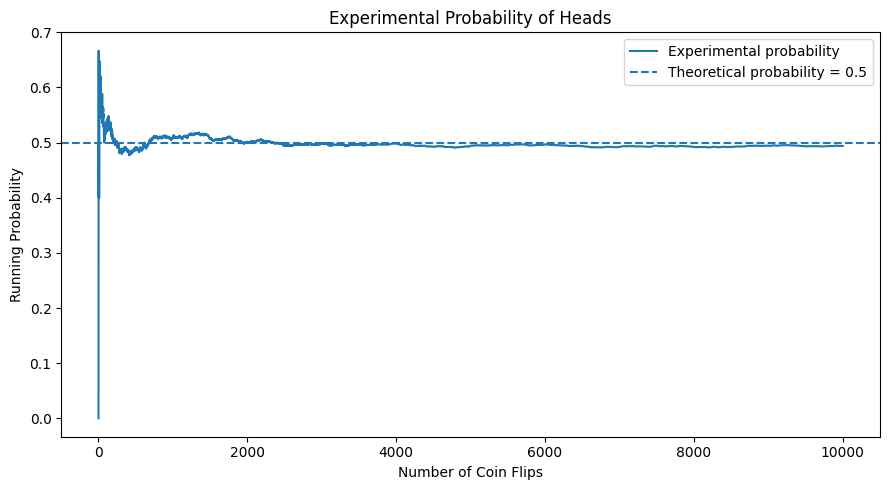

In [14]:
rng = np.random.default_rng(seed=42)

n_flips = 10_000
flips = rng.choice([0, 1], size=n_flips)

running_probability = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(1, n_flips + 1),
    running_probability,
    label="Experimental probability",
)
plt.axhline(
    0.5,
    linestyle="--",
    label="Theoretical probability = 0.5",
)

plt.title("Experimental Probability of Heads")
plt.xlabel("Number of Coin Flips")
plt.ylabel("Running Probability")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

With only a few trials, experimental probability can fluctuate substantially.

As the number of trials grows, the running proportion tends to become more stable around the theoretical probability.

This idea is closely related to the **Law of Large Numbers**, which we will encounter again as our study of probability develops.

## 13. Probability Table

A contingency table makes intersections between categorical events easier to inspect.

In [15]:
probability_table = pd.crosstab(
    df["transport"],
    df["rainy_day"],
    margins=True,
)

probability_table

rainy_day,No,Yes,All
transport,,,
Bicycle,0,11,11
Bus,24,5,29
Car,15,17,32
Train,16,12,28
All,55,45,100


In [16]:
relative_probability_table = pd.crosstab(
    df["transport"],
    df["rainy_day"],
    normalize="all",
    margins=True,
)

relative_probability_table.round(3)

rainy_day,No,Yes,All
transport,,,
Bicycle,0.00,0.11,0.11
Bus,0.24,0.05,0.29
Car,0.15,0.17,0.32
Train,0.16,0.12,0.28
All,0.55,0.45,1.00


## Important Distinctions

Before moving on, keep these ideas separate:

### Theoretical Probability
Derived from a probability model, such as a fair coin or fair die.

### Experimental / Empirical Probability
Estimated from observed or simulated outcomes.

### Independence
Describes whether knowing that one event occurred changes the probability of another event.

### Mutually Exclusive Events
Events that cannot occur at the same time.

Mutually exclusive events are **not generally the same thing as independent events**.

## Exercises

### Exercise 1
Using a fair six-sided die, calculate the probability of rolling:

1. a number greater than 4;
2. an odd number;
3. a number that is not 6.

### Exercise 2
Using the survey dataset, calculate:

1. $P(\text{Car})$
2. $P(\text{Rain})$
3. $P(\text{Car and Rain})$
4. $P(\text{Car or Rain})$

### Exercise 3
Verify the complement rule using the event `rainy_day == "Yes"`.

### Exercise 4
Calculate $P(\text{Bus} \mid \text{Rain})$ and compare it with $P(\text{Bus})$.

### Exercise 5
Simulate 100,000 fair coin flips. How close is the experimental probability of heads to 0.5?

### Exercise 6
Explain in your own words the difference between:

- an outcome;
- an event;
- a sample space;
- theoretical probability;
- experimental probability.

## Summary

In this chapter, you learned the foundations of probability:

- Experiment
- Outcome
- Sample Space
- Event
- Probability
- Complement
- Union
- Intersection
- Independence
- Conditional Probability (preview)
- Theoretical Probability
- Experimental Probability

Probability gives us a framework for reasoning about uncertainty.

In **Chapter 07 — Random Variables**, we will take the next step: representing the outcomes of random experiments numerically.